In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/tabular-playground-series-nov-2021/sample_submission.csv
/kaggle/input/tabular-playground-series-nov-2021/train.csv
/kaggle/input/tabular-playground-series-nov-2021/test.csv


In [2]:
df_train = pd.read_csv('../input/tabular-playground-series-nov-2021/train.csv')
df_test = pd.read_csv('../input/tabular-playground-series-nov-2021/test.csv')
submission = pd.read_csv('../input/tabular-playground-series-nov-2021/sample_submission.csv')

Let's have an overview of the data

In [3]:
print(df_train.info())
print('*****')
print(df_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Columns: 102 entries, id to target
dtypes: float64(100), int64(2)
memory usage: 466.9 MB
None
*****
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 540000 entries, 0 to 539999
Columns: 101 entries, id to f99
dtypes: float64(100), int64(1)
memory usage: 416.1 MB
None


In [4]:
print(df_train.shape)
print(df_test.shape)

(600000, 102)
(540000, 101)


In [5]:
features = [col for col in df_train.columns if 'f' in col]

In [6]:
print(features)

['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21', 'f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f31', 'f32', 'f33', 'f34', 'f35', 'f36', 'f37', 'f38', 'f39', 'f40', 'f41', 'f42', 'f43', 'f44', 'f45', 'f46', 'f47', 'f48', 'f49', 'f50', 'f51', 'f52', 'f53', 'f54', 'f55', 'f56', 'f57', 'f58', 'f59', 'f60', 'f61', 'f62', 'f63', 'f64', 'f65', 'f66', 'f67', 'f68', 'f69', 'f70', 'f71', 'f72', 'f73', 'f74', 'f75', 'f76', 'f77', 'f78', 'f79', 'f80', 'f81', 'f82', 'f83', 'f84', 'f85', 'f86', 'f87', 'f88', 'f89', 'f90', 'f91', 'f92', 'f93', 'f94', 'f95', 'f96', 'f97', 'f98', 'f99']


### Observing the test data

<AxesSubplot:xlabel='target', ylabel='count'>

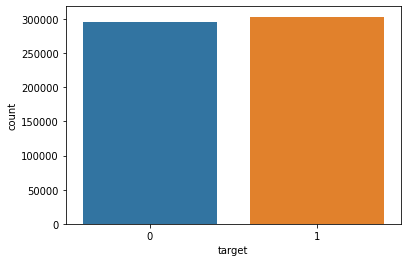

In [7]:
import seaborn as sns

sns.countplot(x = 'target', data = df_train)

### Conclusion
The distribution of data with target = 0  and target = 1 made are the same. This is one less thing to worry about :)

### Observing the distribution of data in the train and test set

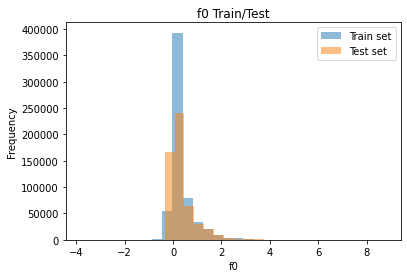

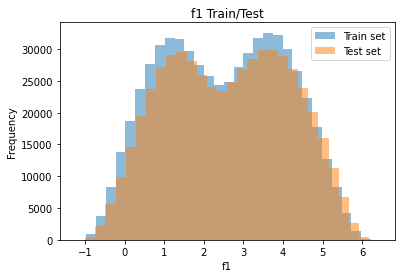

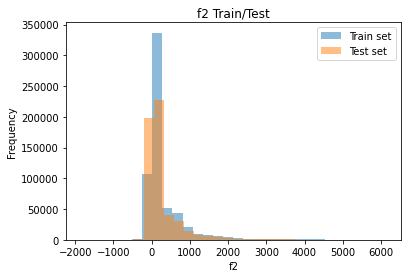

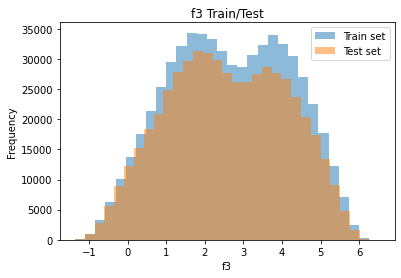

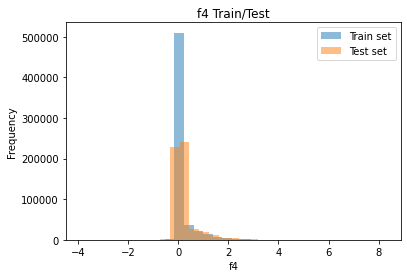

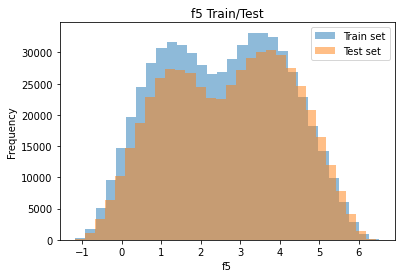

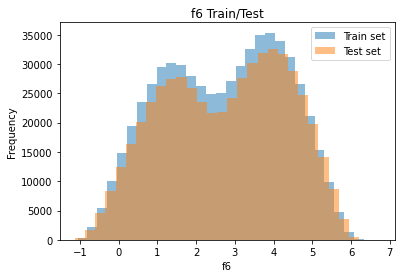

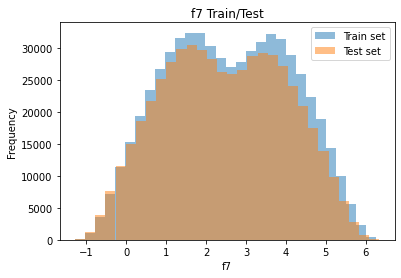

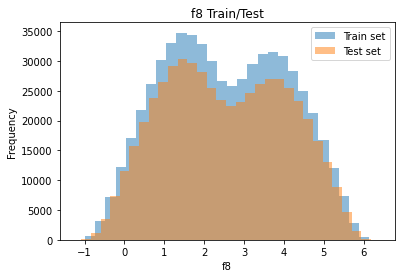

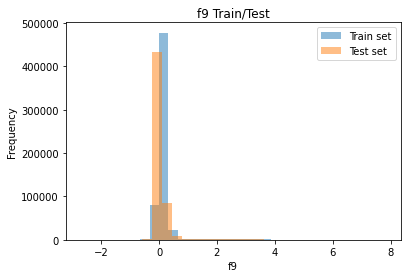

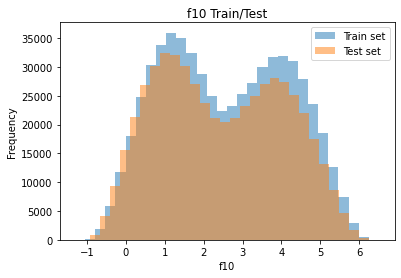

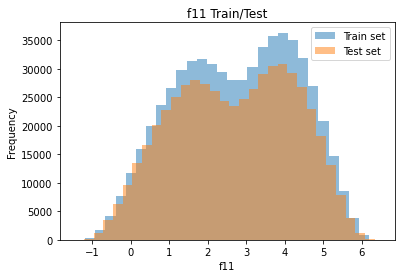

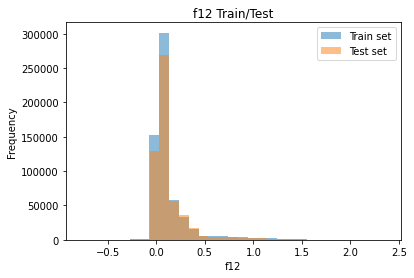

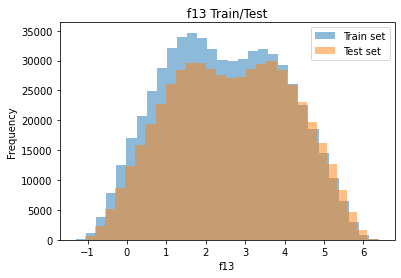

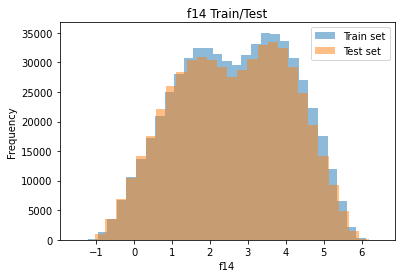

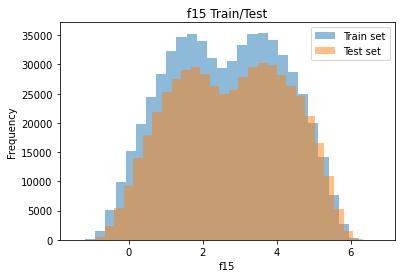

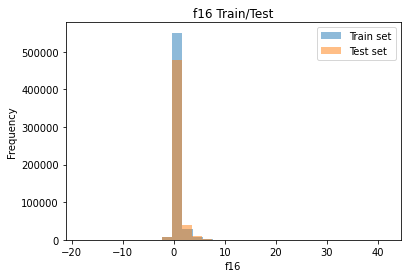

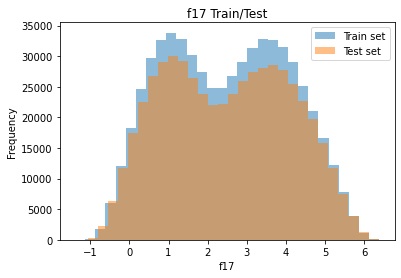

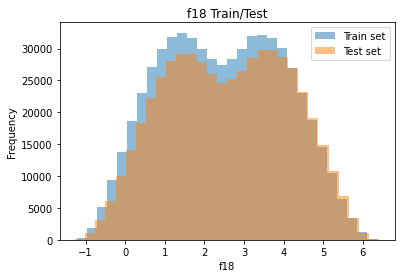

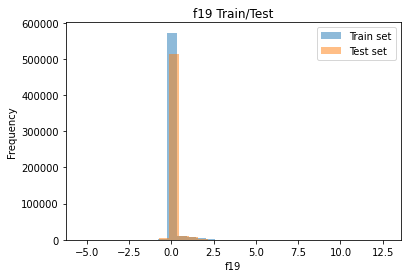

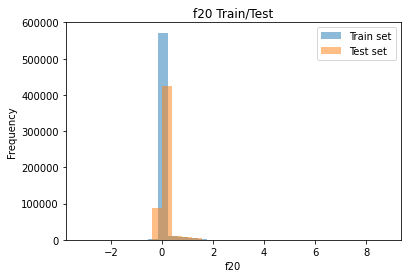

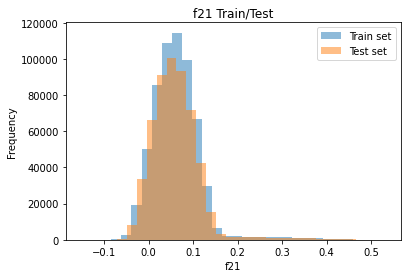

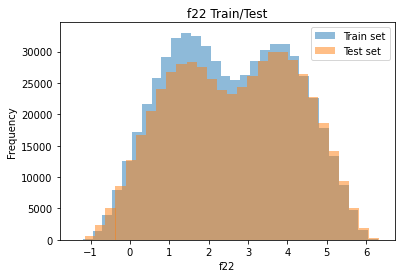

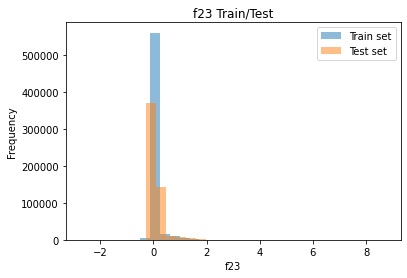

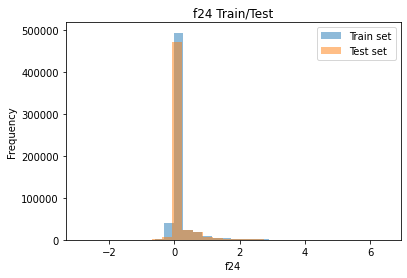

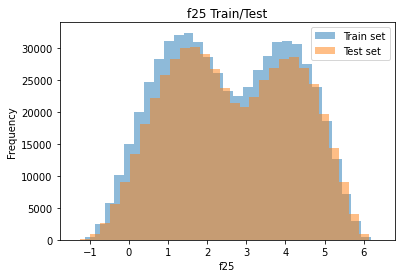

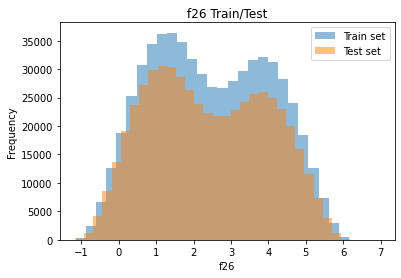

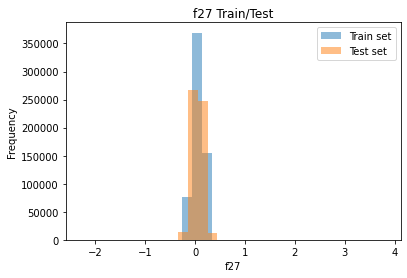

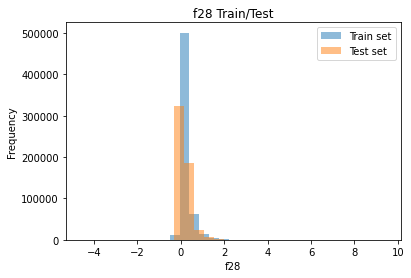

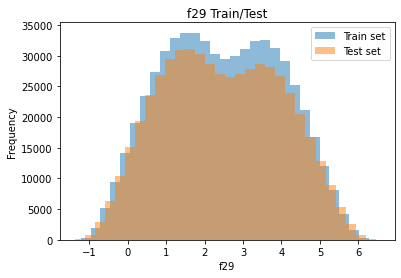

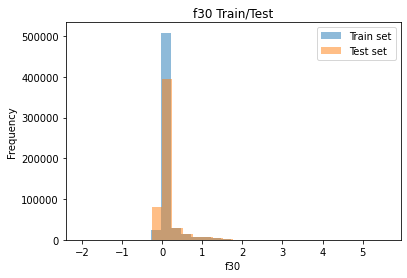

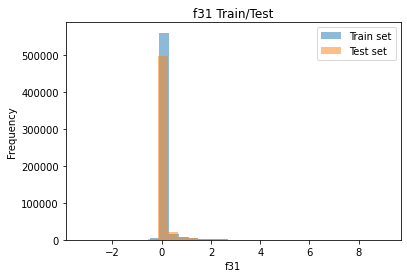

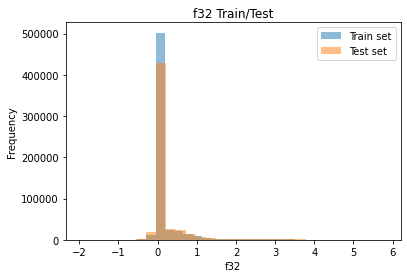

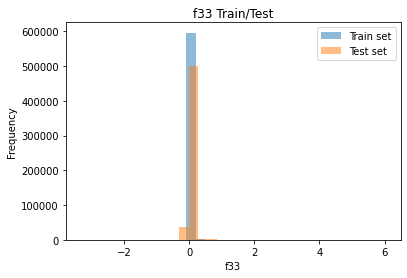

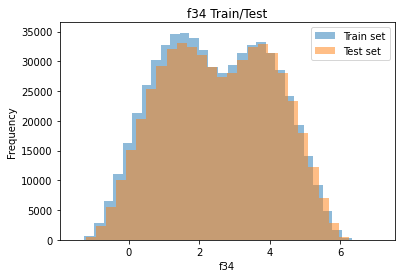

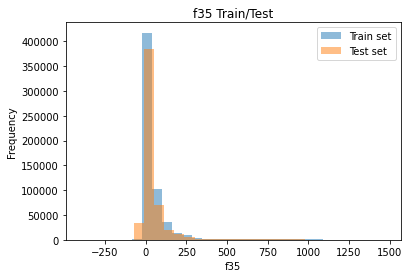

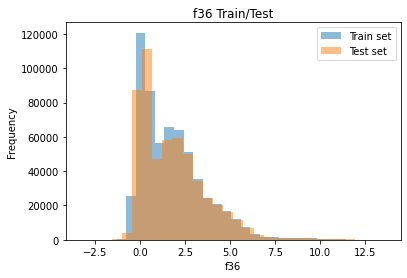

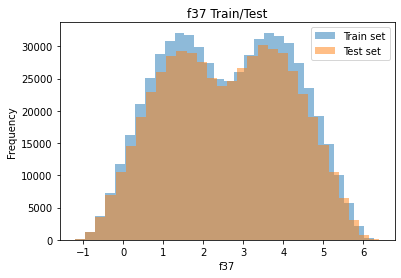

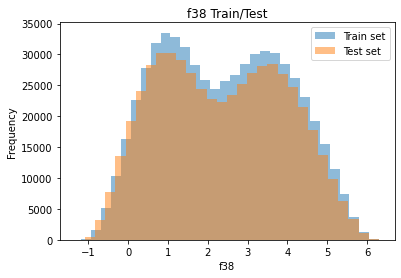

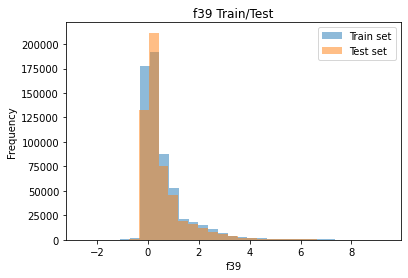

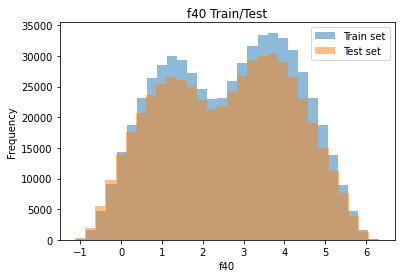

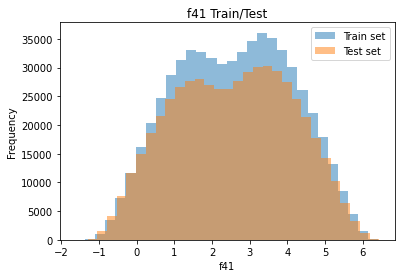

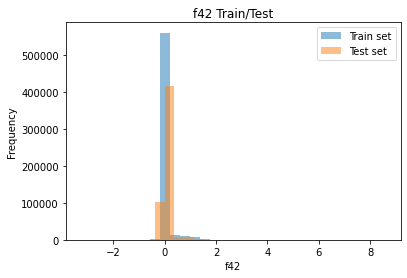

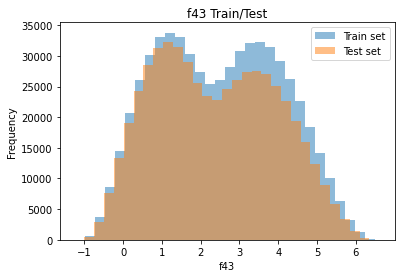

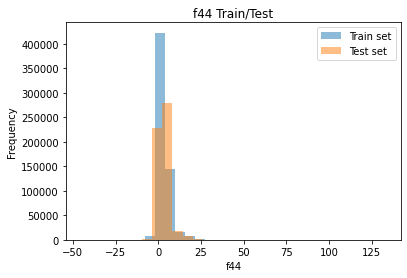

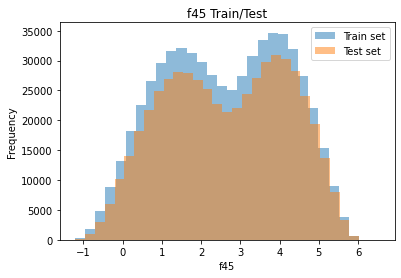

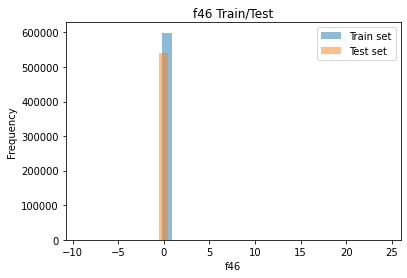

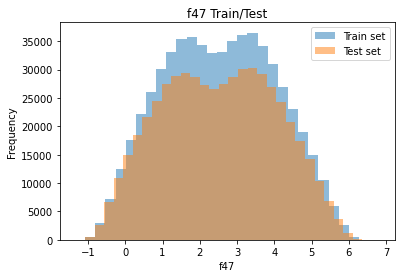

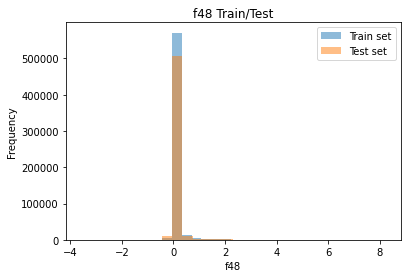

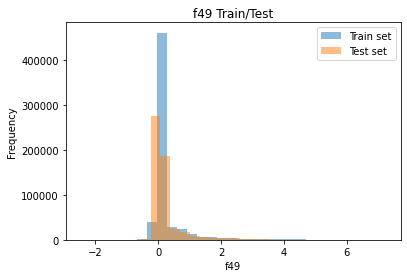

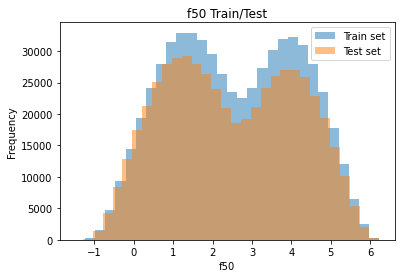

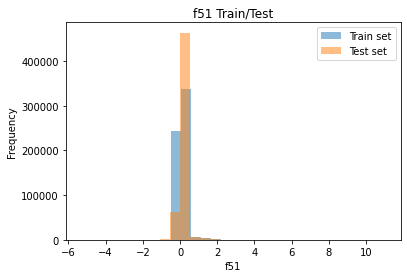

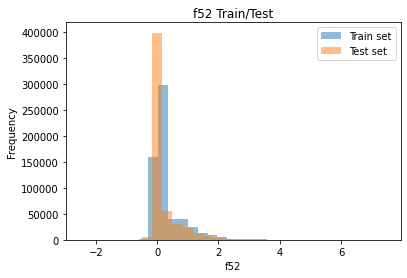

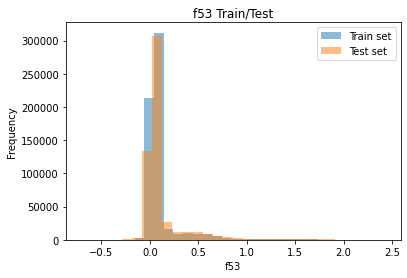

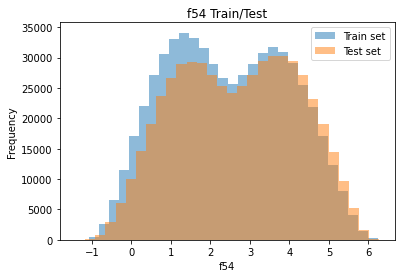

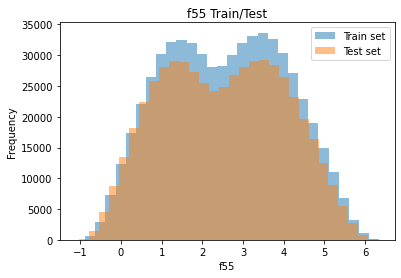

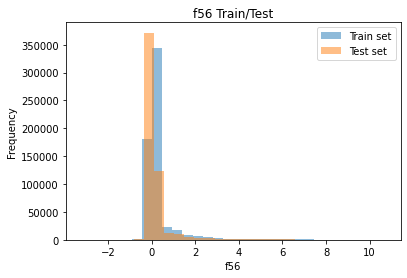

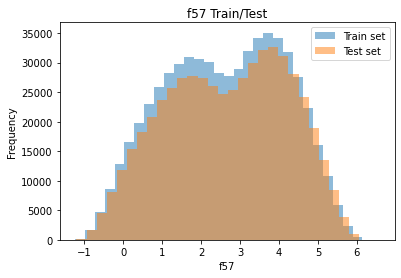

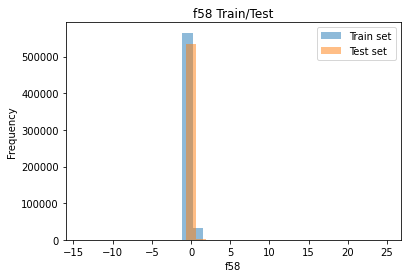

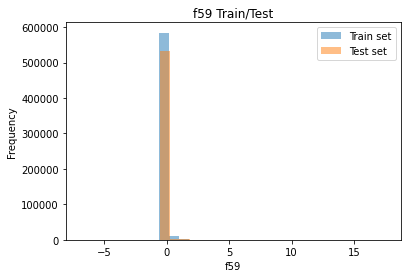

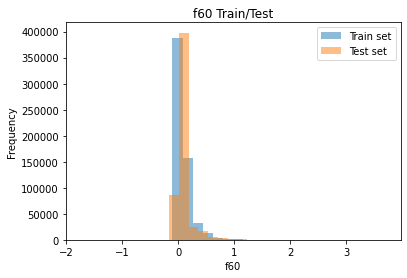

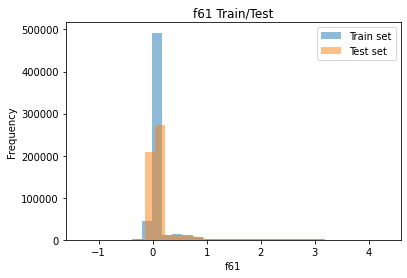

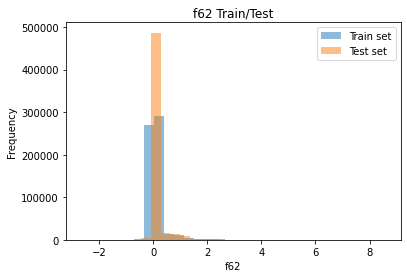

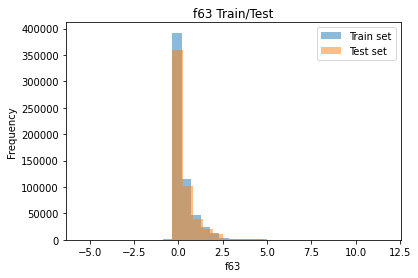

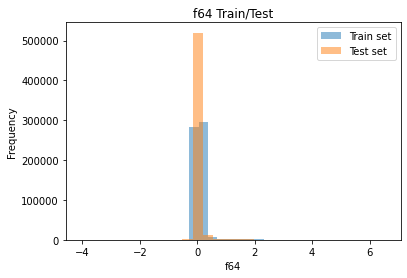

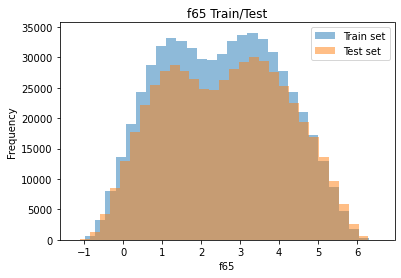

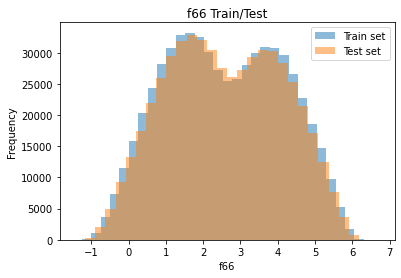

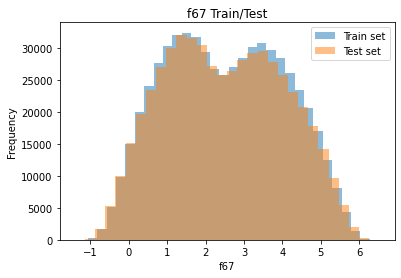

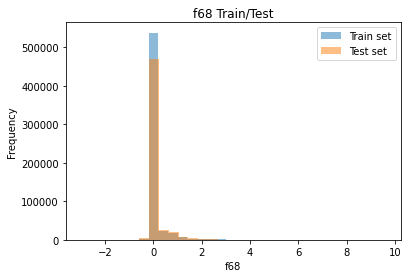

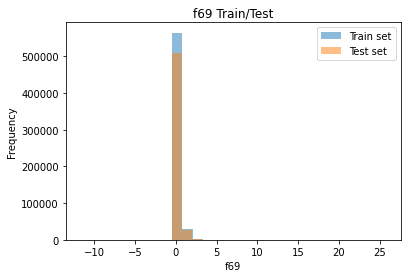

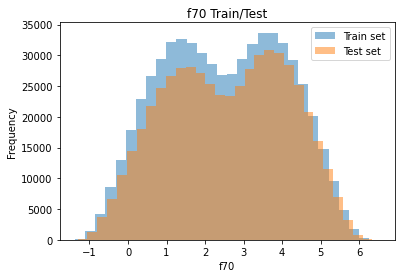

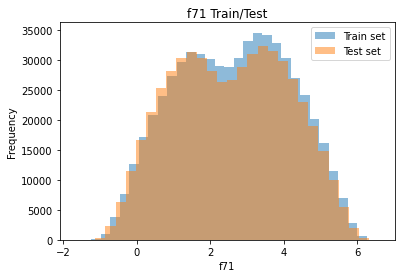

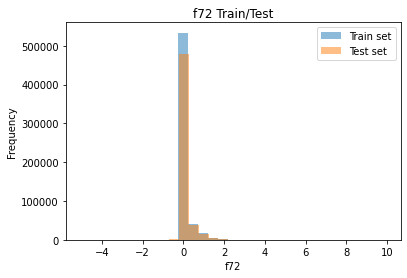

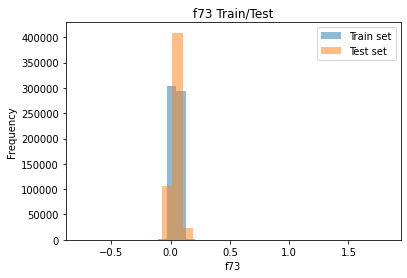

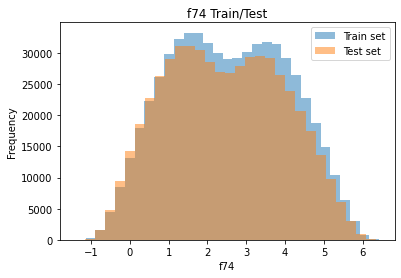

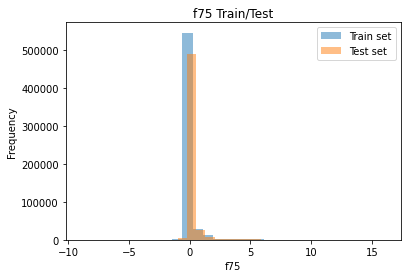

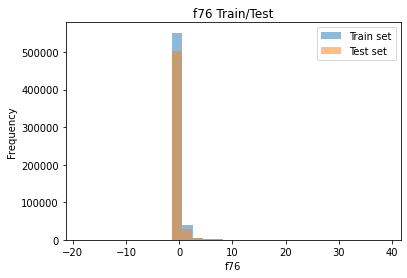

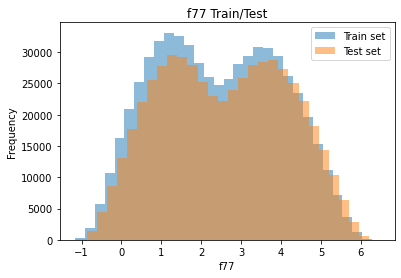

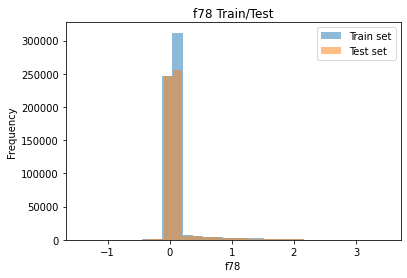

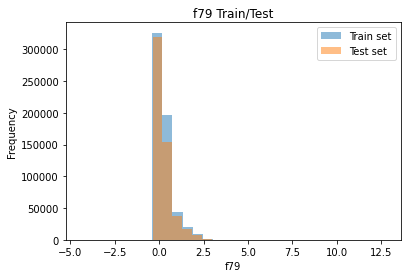

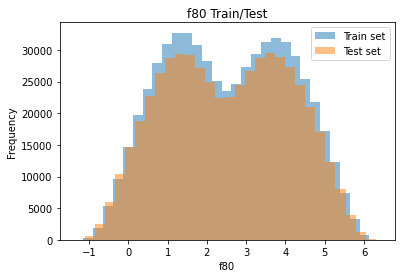

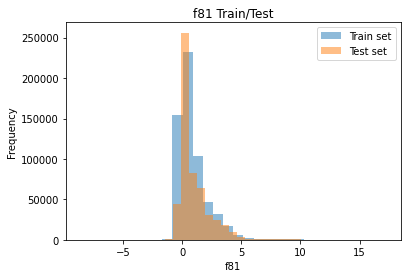

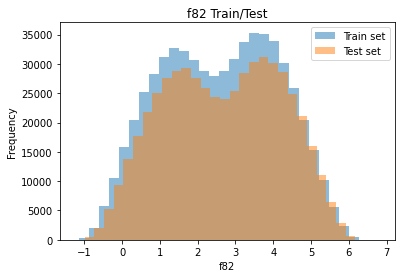

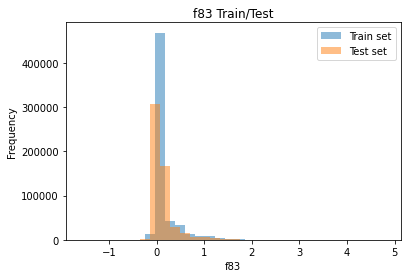

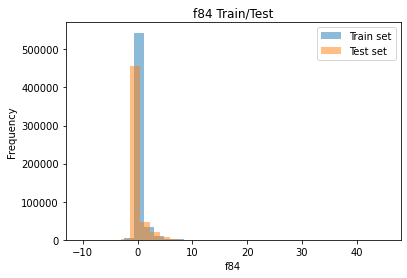

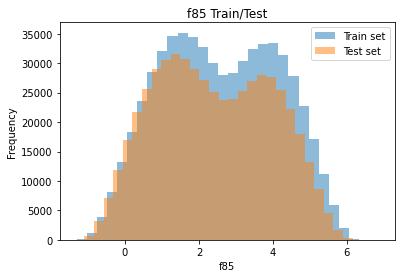

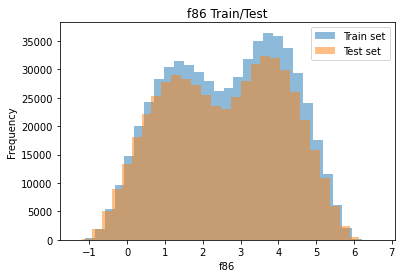

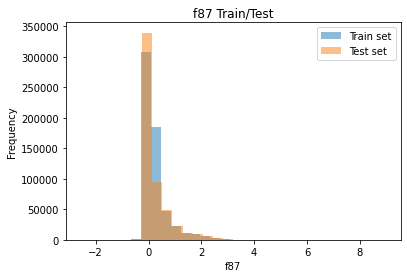

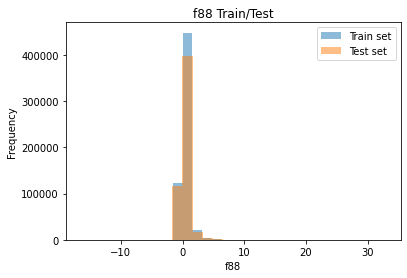

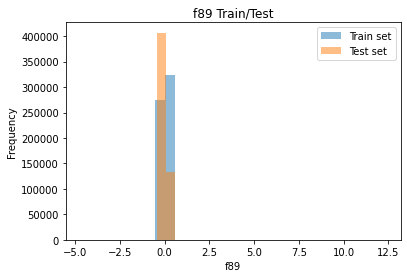

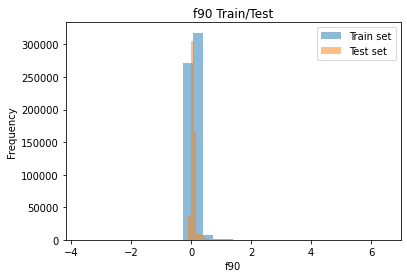

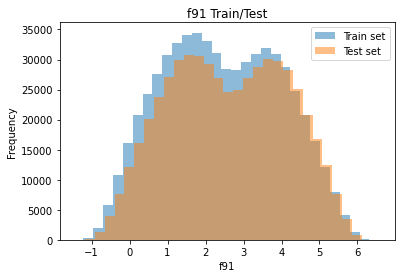

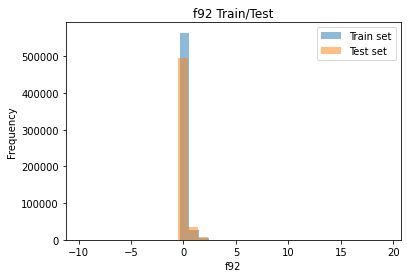

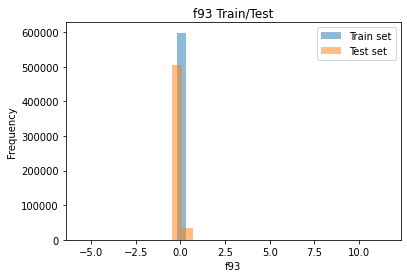

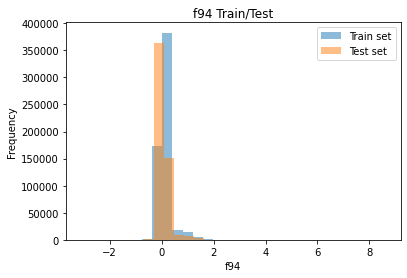

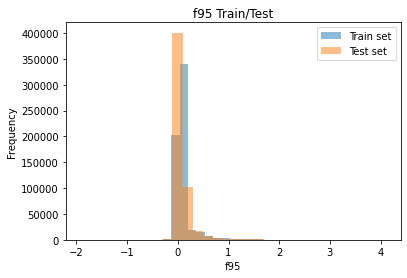

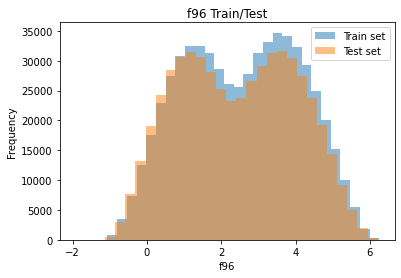

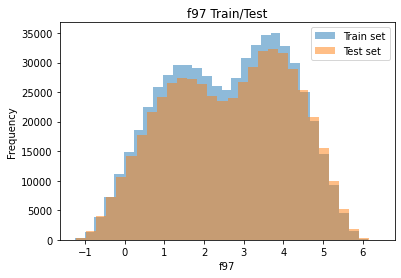

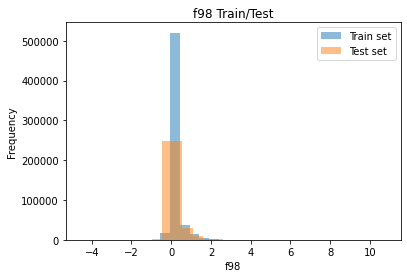

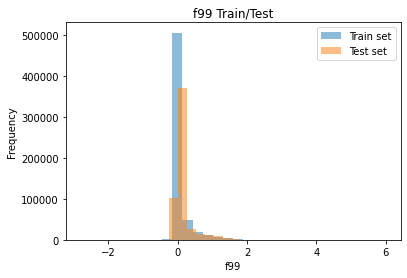

In [8]:
import matplotlib.pyplot as plt

for idx, feature in enumerate(features):
    plt.hist(df_train[feature], bins=30, alpha=0.5, label='Train set')
    plt.hist(df_test[feature], bins=30, alpha=0.5, label='Test set')
    plt.title(feature + " Train/Test")
    plt.xlabel(feature)
    plt.ylabel('Frequency')

    plt.legend()
    plt.show()

### Conclusion

The train and test data distribution are similar. This is great!!!

In [9]:
print(df_train[features].isna().sum().sum())
print(df_test[features].isna().sum().sum())

0
0


### No missing values in train and test data. That is one less thing to worry about

In [10]:
X = df_train[features].copy()
y = df_train['target'].copy()

x_test = df_test[features].copy()

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X[features] = scaler.fit_transform(X[features])
x_test[features] = scaler.transform(x_test[features])

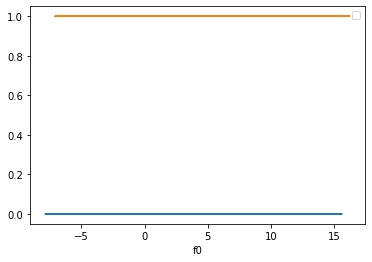

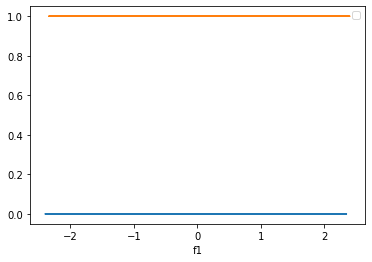

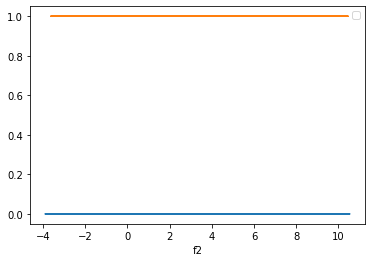

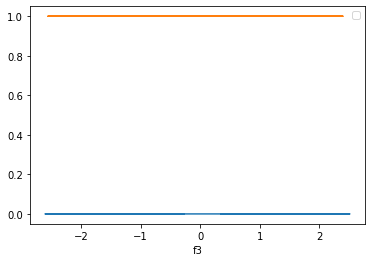

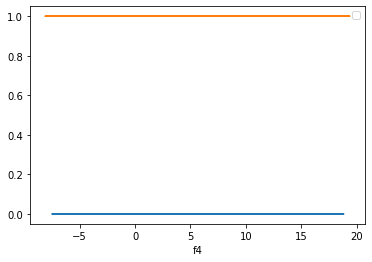

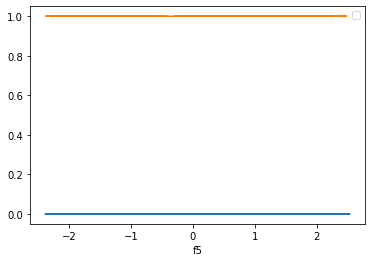

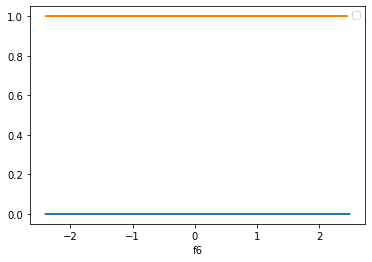

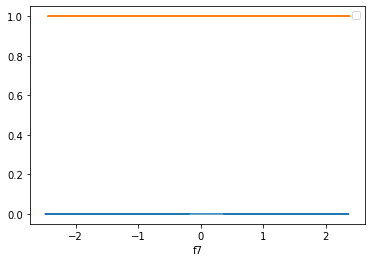

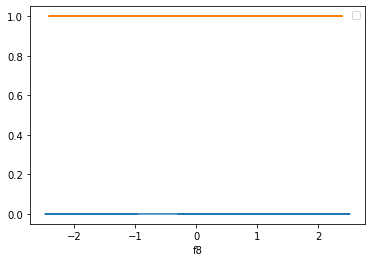

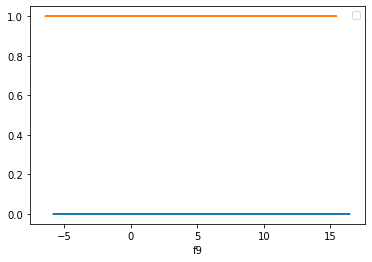

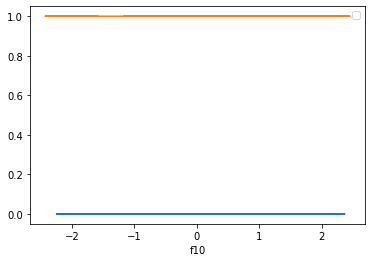

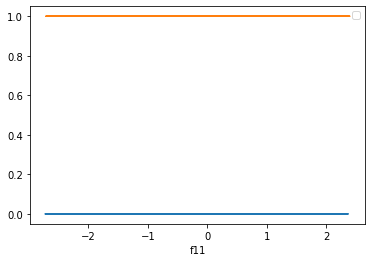

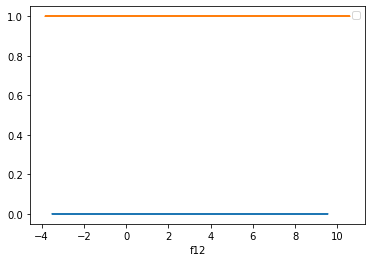

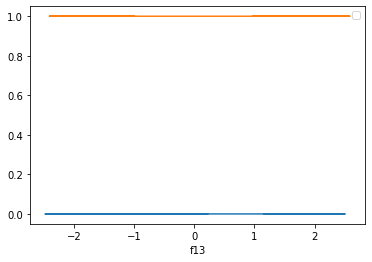

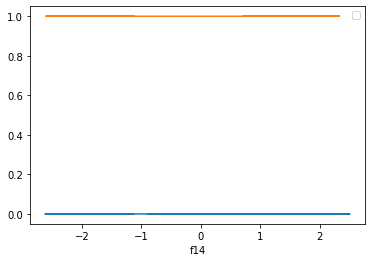

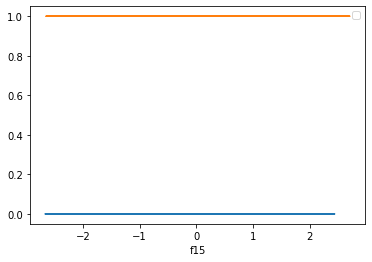

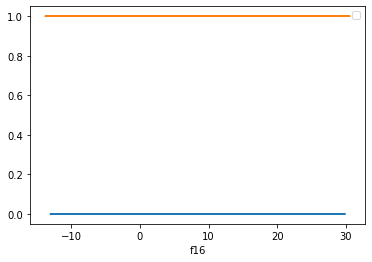

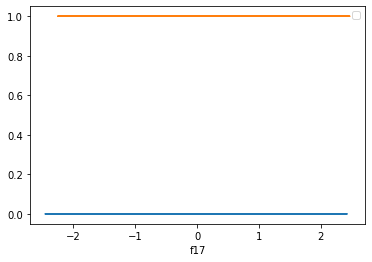

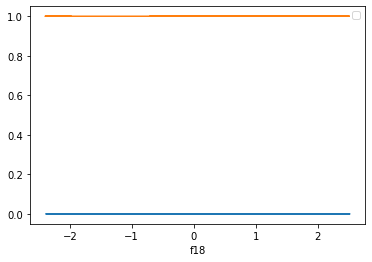

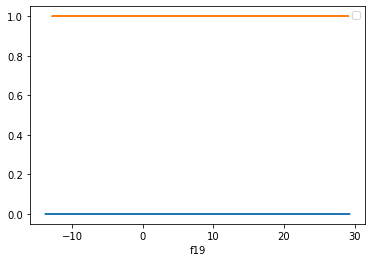

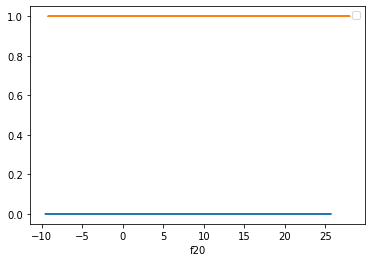

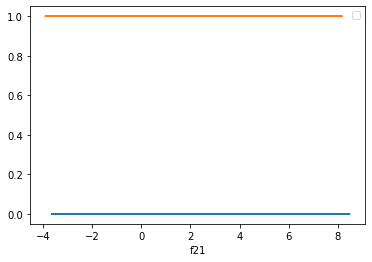

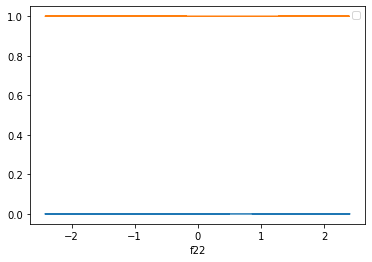

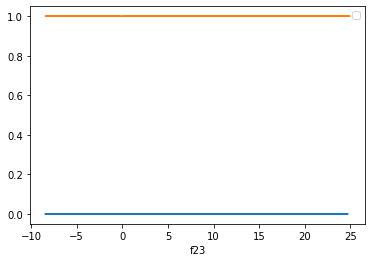

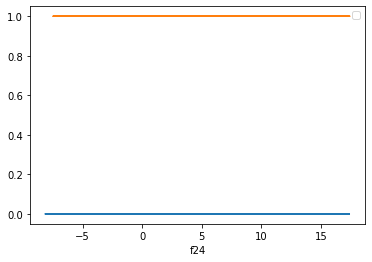

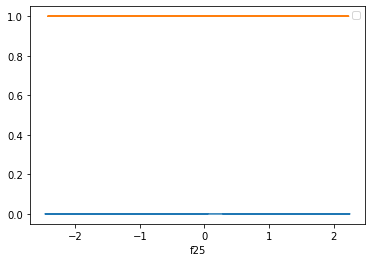

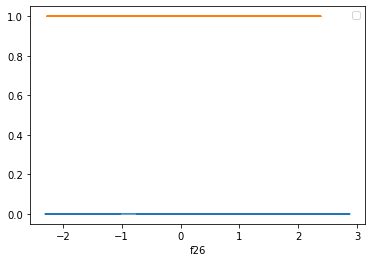

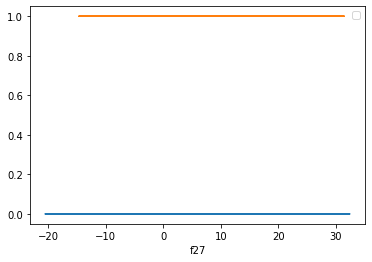

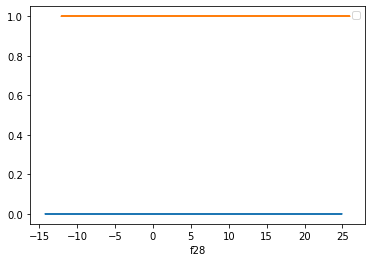

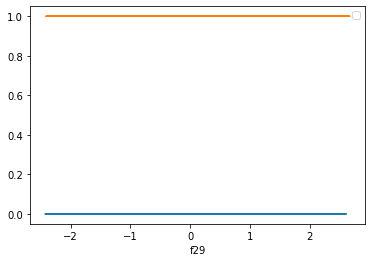

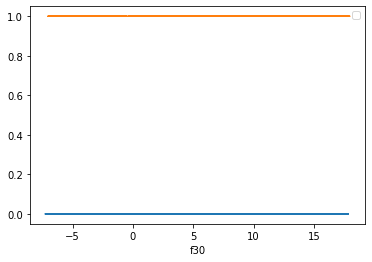

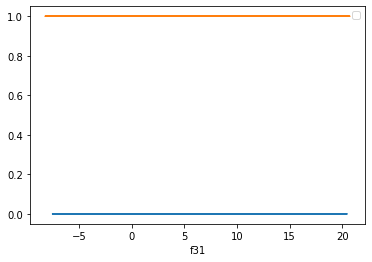

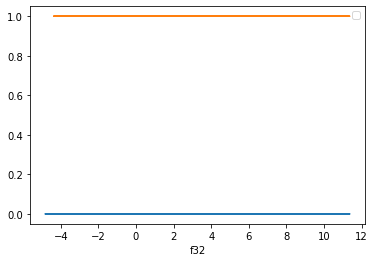

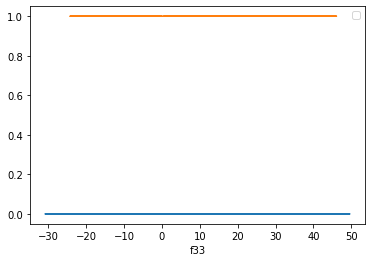

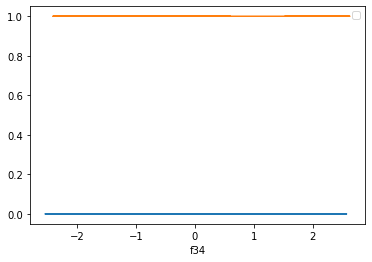

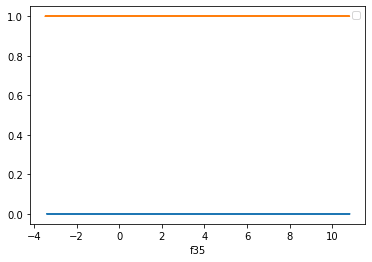

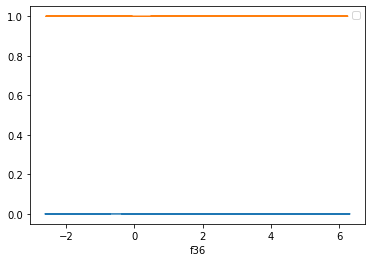

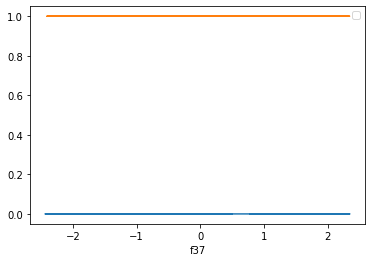

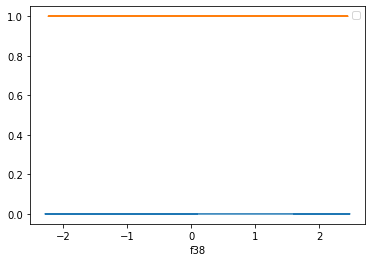

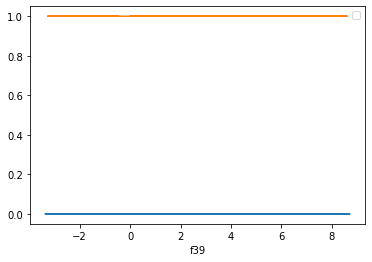

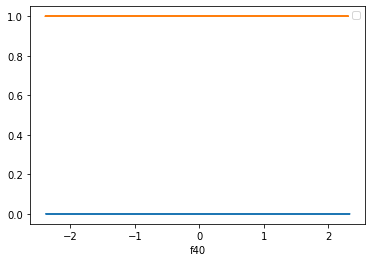

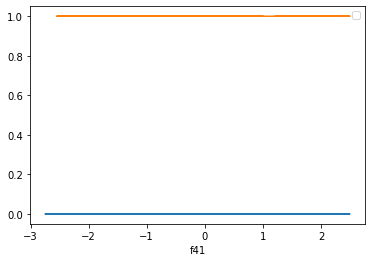

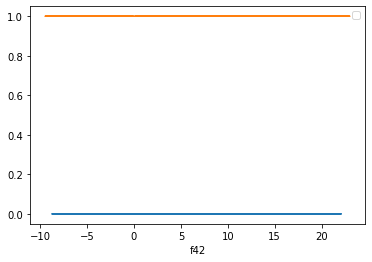

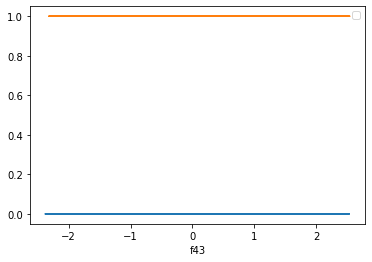

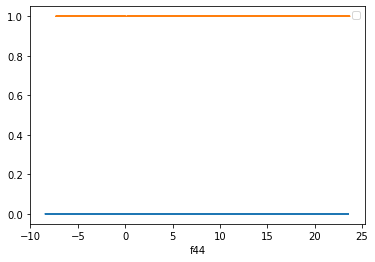

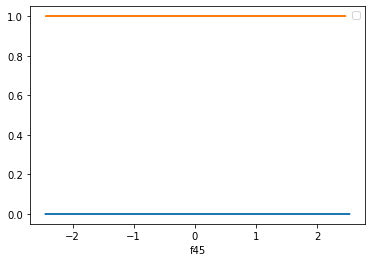

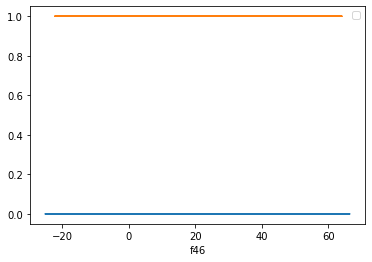

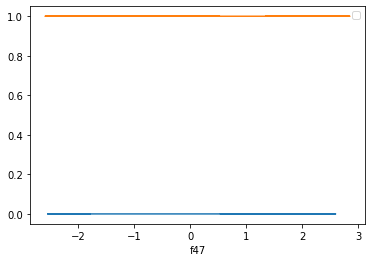

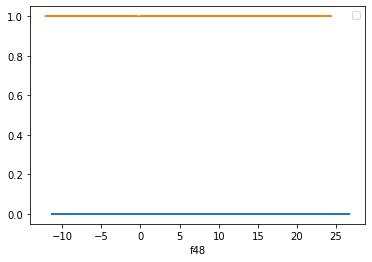

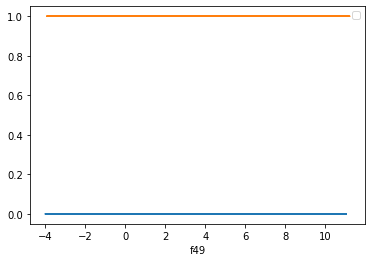

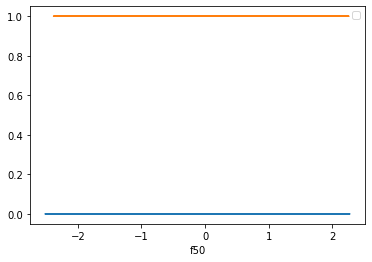

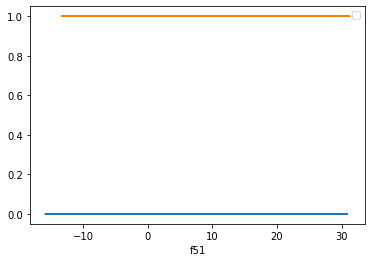

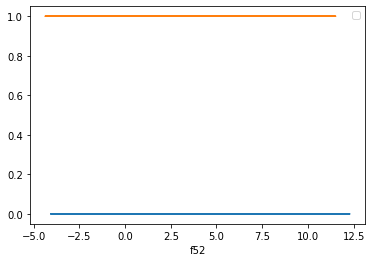

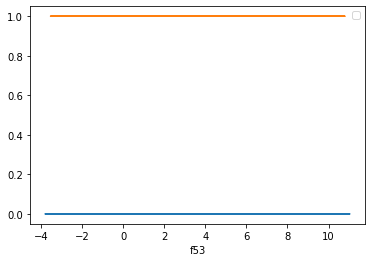

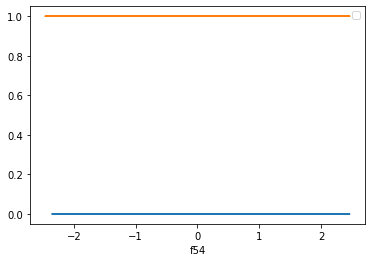

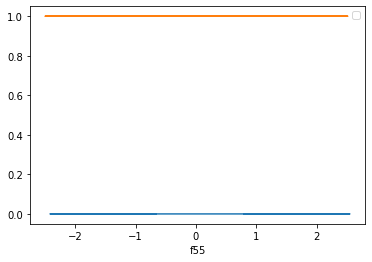

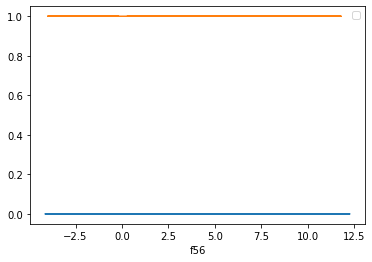

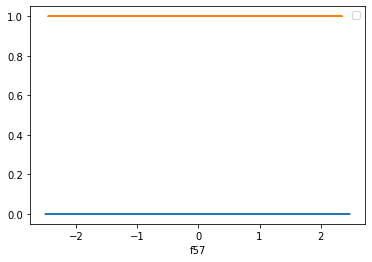

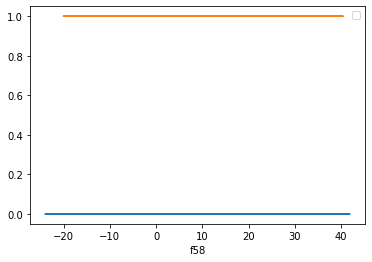

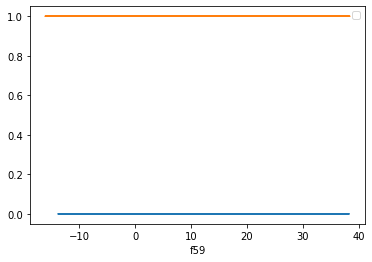

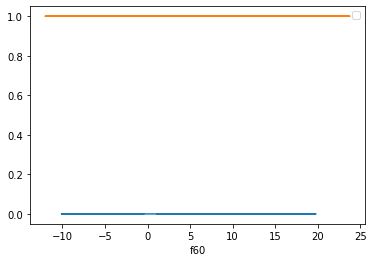

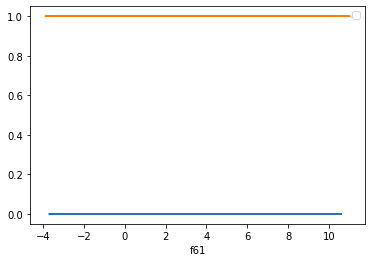

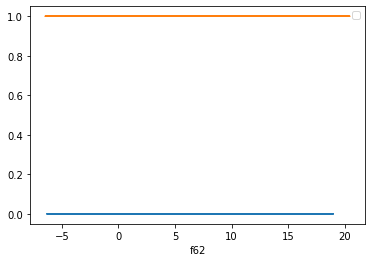

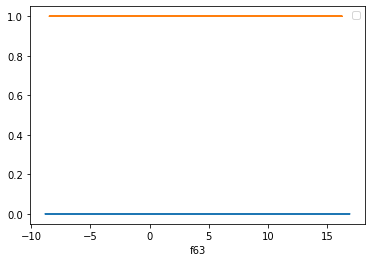

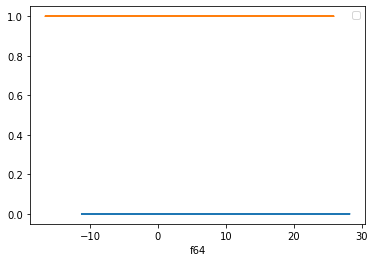

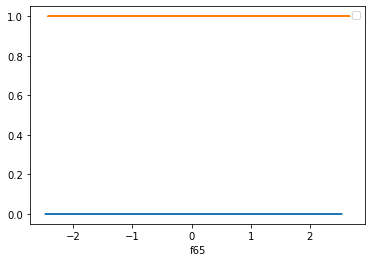

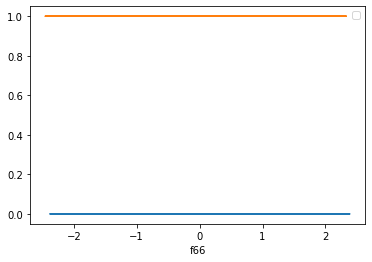

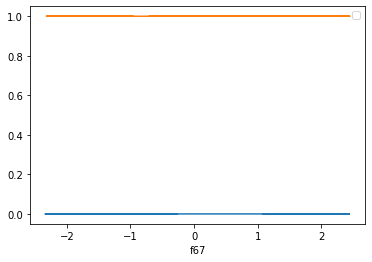

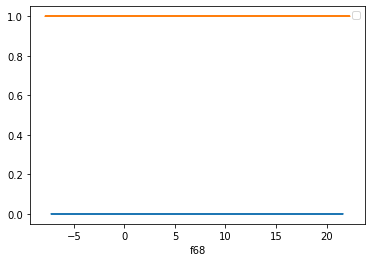

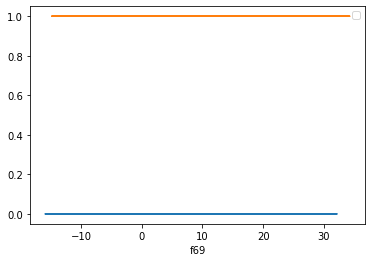

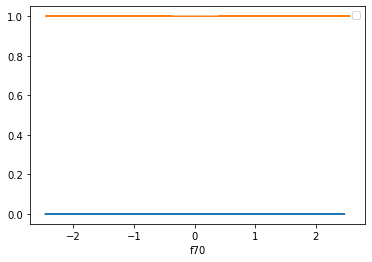

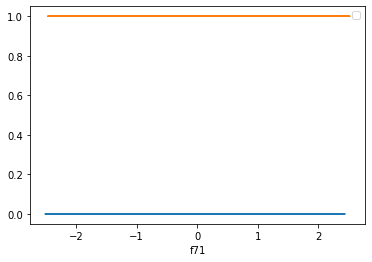

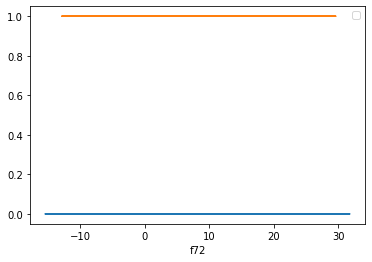

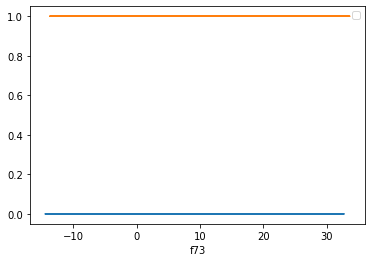

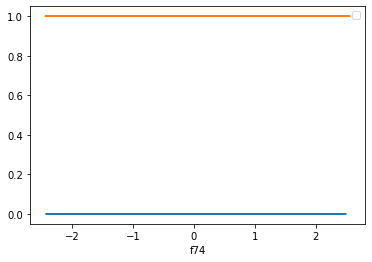

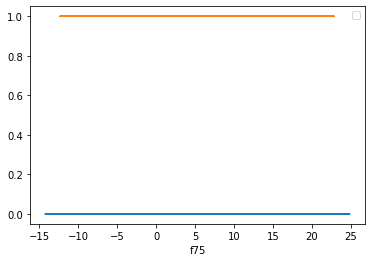

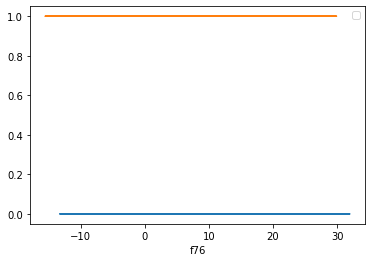

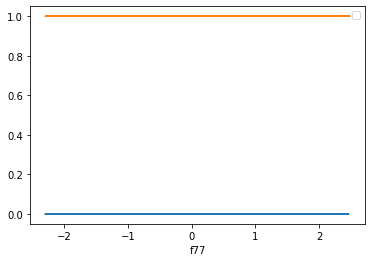

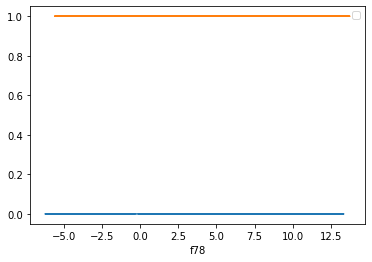

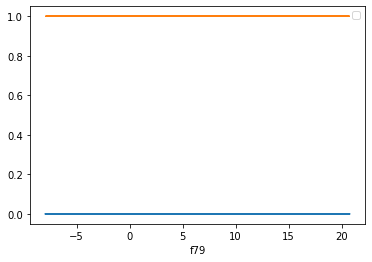

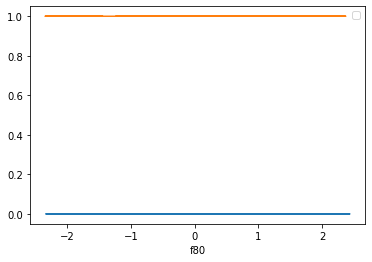

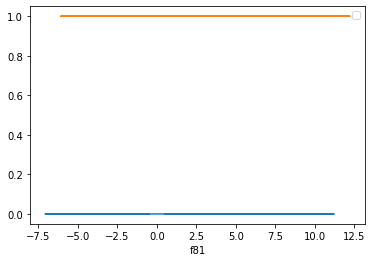

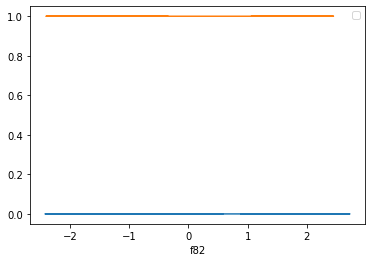

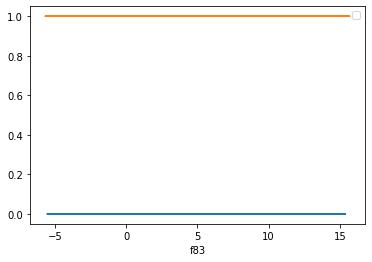

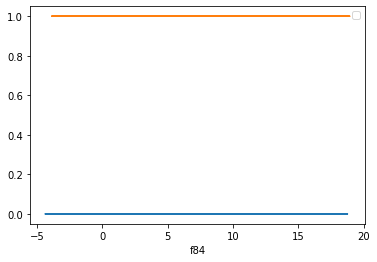

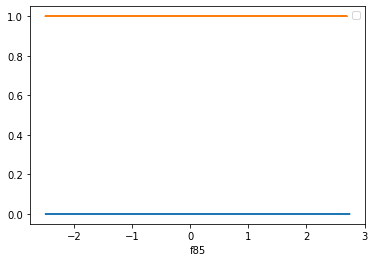

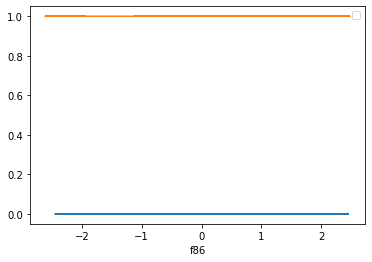

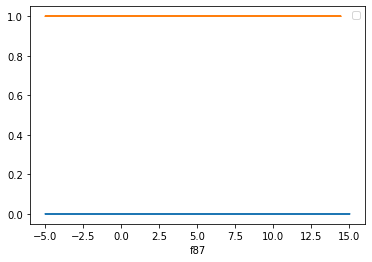

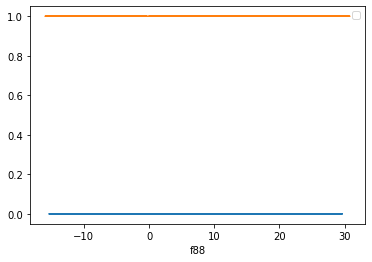

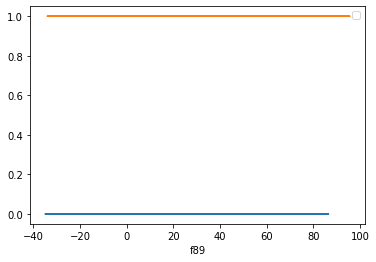

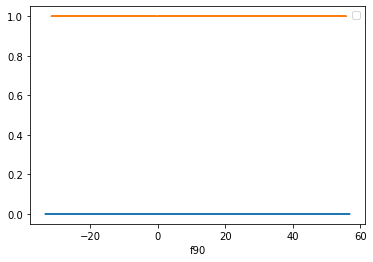

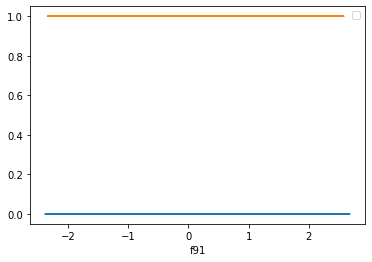

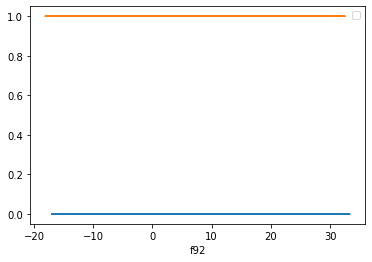

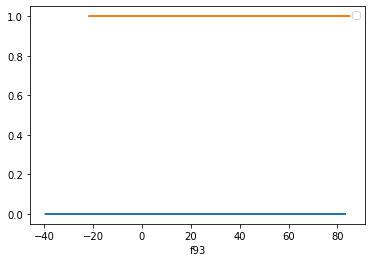

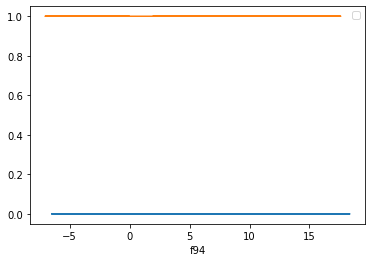

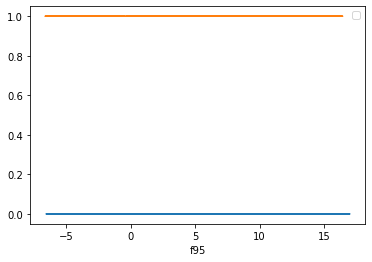

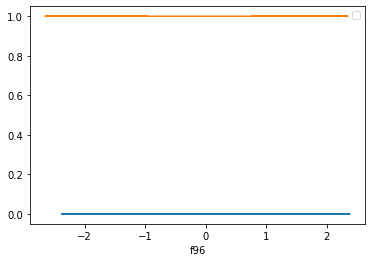

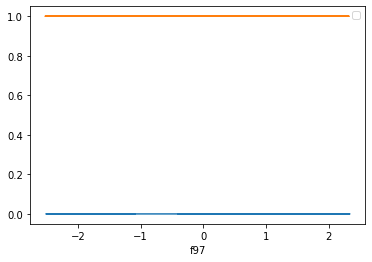

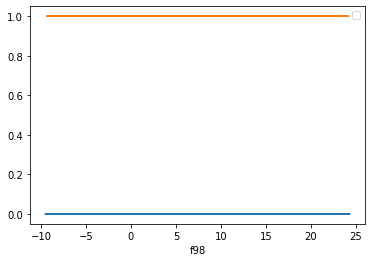

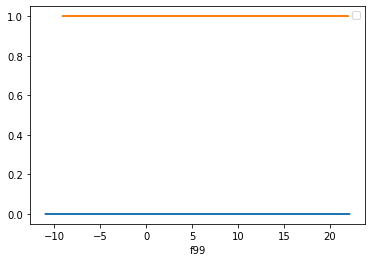

In [12]:
for idx, feature in enumerate(features):
    plt.plot(X[df_train['target']==0][feature], df_train.loc[df_train['target']==0]['target'])
    plt.plot(X[df_train['target']==1][feature], df_train.loc[df_train['target']==1]['target'])
    plt.xlabel(feature)

    plt.legend()
    plt.show()

The range of value for each feature is the same for target value = 0 and target value = 1

## Implementing Logistic Regression model

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
model = LogisticRegression(random_state=0)
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

In [14]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
  
print ("Confusion Matrix : \n", cm)

Confusion Matrix : 
 [[71488 26309]
 [25377 74826]]


### True positive + True negative = 71488 + 74826 = 146314
### False positive + False negative = 26309 + 25377 = 51686

In [15]:
from sklearn.metrics import accuracy_score
print ("Accuracy : ", accuracy_score(y_test, y_pred))

Accuracy :  0.7389595959595959


In [16]:
logistic_prediction = model.predict(x_test)

In [17]:
logistic_csv = pd.DataFrame()
logistic_csv['id'] = df_test['id']
logistic_csv['target'] = logistic_prediction

In [18]:
logistic_csv.to_csv('logistic', index=False)